# Data Preparation:
I used discretization to convert the continuous target variable (number of Rings) into categorical age groups. I defined three intervals — Young (1–5), Adult (6–10), and Old (11 and above) — to simplify the prediction task and make the model more interpretable. This rings are corresponding to the age of the abalones.

In [35]:
import numpy
import pandas as pd
from ucimlrepo import fetch_ucirepo 

# fetch datasets
abalone = fetch_ucirepo(id=1) 

targets = abalone.data.targets.values.flatten().astype(int)
X = abalone.data.features.values

LABELS = ["Young", "Adult", "Old"]

# custom bins
bins = [0, 5, 10, numpy.max(targets) + 1]  # +1 to include max value
y = pd.cut(targets, bins=bins, labels=LABELS, right=True)

DT_TRESHOLD = 0.01
K_FOLDS = 5
RANDOM_STATE = 91

y.value_counts()

Young     189
Adult    2541
Old      1447
Name: count, dtype: int64

# Utils:
Utility for confusion matrix plotting

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrices(confusion_matrices, class_labels, normalize=False):
	num_folds = len(confusion_matrices)

	fig, axes = plt.subplots(1, num_folds, figsize=(5 * num_folds, 5))

	if num_folds == 1:
		axes = [axes]  # make it iterable

	for i, (cm, ax) in enumerate(zip(confusion_matrices, axes)):
		if normalize:
			cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
			cm = np.nan_to_num(cm)  # handle division by zero

		sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
					xticklabels=class_labels, yticklabels=class_labels,
					cmap="Blues", ax=ax)

		ax.set_title(f"Fold {i+1}")
		ax.set_xlabel("Predicted Label")
		ax.set_ylabel("True Label")

	plt.tight_layout()
	plt.show()


# **Implementation of Desicion Tree Modeling Function:**
In my decision tree implementation, for numeric features, I sort the feature values and determine potential split points by calculating the average of two consecutive values. For categorical features, I split the data into as many branches as there are unique categories. After each split, I calculate the entropy for each branch individually and compute a weighted average entropy, giving more weight to branches with more samples. In the base case of tree building, I calculate the node entropy by counting the number of samples for each label and applying the entropy formula over these counts.

In [4]:
def construct_feature_type_vector(X) -> list:
	if len(X) == 0:
		raise ValueError("The classification dictionary is empty.")

	feature_vector = X[0]

	type_vector = []
	for feature in feature_vector:
		if isinstance(feature, (int, float)):
			type_vector.append("numeric")
		else:
			type_vector.append("categorical")
	
	return type_vector


class Node:
	def __init__(self, value=None):
		self.value = value
		self.left: Node = None
		self.right: Node = None
		self.bestFeature: int = None
		self.bestCategory: str = None
		self.bestSplit: int = None
  
def MajorityVote(y):
	counts = {}
	for label in y:
		if label not in counts:
			counts[label] = 0
		counts[label] += 1
	return max(counts, key=counts.get)

def NodeEntropy(X, y):
	counts = {}
	for label in y:
		if label not in counts:
			counts[label] = 0
		counts[label] += 1
	
	entropy = 0
	for count in counts.values():
		p = count / len(y)
		entropy -= p * numpy.log2(p)
	return entropy

def splitNode(X, y, feature_index, split_value) -> tuple:
	X_left = []
	y_left = []
	X_right = []
	y_right = []

	for x, label in zip(X, y):
		# Check if the feature is numeric or categorical depending on split_Value isinstance str
		if isinstance(split_value, str):
			if x[feature_index] == split_value:
				X_left.append(x)
				y_left.append(label)
			else:
				X_right.append(x)
				y_right.append(label)
		elif x[feature_index] < split_value:
			X_left.append(x)
			y_left.append(label)
		else:
			X_right.append(x)
			y_right.append(label)

	return X_left, y_left, X_right, y_right

def split_attribute(X, y, attribute_types: list) -> tuple:
	minEnt = float("inf")
	bestFeature = None
	bestCategory = None
	bestSplit = None
 
	for i in range(len(attribute_types)):
		if attribute_types[i] == "numeric":
			sorted_X = sorted(X, key=lambda x: x[i]) # sort the data by the i-th 

			for j in range(len(sorted_X) - 1):
				if sorted_X[j][i] == sorted_X[j + 1][i]:
					continue
 
				# mid point split
				trialSplit = (sorted_X[j][i] + sorted_X[j + 1][i]) / 2
	
				X_left, y_left, X_right, y_right = splitNode(X, y, i, trialSplit)
	
				# Calculate the entropy of the split
				entropyLeft = NodeEntropy(X_left, y_left)
				entropyRight = NodeEntropy(X_right, y_right)
				# weighted entropy
				weightedEntropy = (len(X_left) / len(X)) * entropyLeft + (len(X_right) / len(X)) * entropyRight
				if weightedEntropy < minEnt:
					minEnt = weightedEntropy
					bestFeature = i
					bestCategory = None
					bestSplit = trialSplit
   
		else: # categoric
			categories = set(x[i] for x in X) # get the categories
   
			for category in categories:
				X_left, y_left, X_right, y_right = splitNode(X, y, i, category)

				# Calculate the entropy of the split
				entropyLeft = NodeEntropy(X_left, y_left)
				entropyRight = NodeEntropy(X_right, y_right)

				# weighted entropy
				weightedEntropy = (len(X_left) / len(X)) * entropyLeft + (len(X_right) / len(X)) * entropyRight
				if weightedEntropy < minEnt:
					minEnt = weightedEntropy
					bestFeature = i
					bestCategory = category
					bestSplit = None
	
	return bestFeature, bestCategory, bestSplit
   
def build_dt(X, y, attribute_types: list, options=[DT_TRESHOLD]) -> Node:
	if options is None:
		options = [DT_TRESHOLD]
	
	# Pre-pruning strategy
	max_depth = options[1] if len(options) > 1 else None
 
	if max_depth is None:
		max_depth = 100 # to avoid infinite recursion
  
	# Create Leaf Node (Base Case)
	if NodeEntropy(X, y) < options[0] or \
	 	(max_depth is not None and max_depth <= 0):
		return Node(MajorityVote(y))
	
	bestFeature, bestCategory, bestSplit = split_attribute(X, y, attribute_types)

	# Check if no valid split was found
	if bestFeature is None:
		return Node(MajorityVote(y))

	# Create Internal Node
	node = Node()
	node.bestFeature = bestFeature
	node.bestCategory = bestCategory
	node.bestSplit = bestSplit

	# Pruning
	new_options = options.copy()
	if max_depth is not None:
		max_depth -= 1
		if len(new_options) > 1:
			new_options[1] = max_depth
		else:
			new_options.append(max_depth)

	
	X_left, y_left, X_right, y_right = None, None, None, None
 
	if attribute_types[bestFeature] == "numeric":
		X_left, y_left, X_right, y_right = splitNode(X, y, bestFeature, bestSplit)
	else: # categoric
		X_left, y_left, X_right, y_right = splitNode(X, y, bestFeature, bestCategory)

	if y_left:
		node.left = build_dt(X_left, y_left, attribute_types, new_options)
	else:
		node.left = Node(MajorityVote(y))

	if y_right:
		node.right = build_dt(X_right, y_right, attribute_types, new_options)
	else:
		node.right = Node(MajorityVote(y))

	# Check if the node is a leaf node
	if node.left is None and node.right is None:
		node.value = MajorityVote(y)
		return node

	return node

def predict_value(dt: Node, X):
	if dt.value is not None:
		return dt.value
	elif dt.bestSplit is not None and isinstance(X[dt.bestFeature], (int, float)):
		if X[dt.bestFeature] < dt.bestSplit:
			return predict_value(dt.left, X)
		else:
			return predict_value(dt.right, X)
	else:
		if X[dt.bestFeature] == dt.bestCategory:
			return predict_value(dt.left, X)
		else:
			return predict_value(dt.right, X)

def predict_dt(dt: Node, X, options=None):
	predictions = []
	for x in X:
		predictions.append(predict_value(dt, x))
	return predictions

# **Implementation of Decision Tree Testing Function:**

In [5]:
import time

def k_fold_cross_validation_dt(X, y, k_fold: int=K_FOLDS, options=None):
	if k_fold < 1:
		raise ValueError("k_fold must be greater than 0")
	
	if len(y) == 0:
		raise ValueError("data must not be empty")

	if k_fold > len(y):
		k_fold = len(y)

	data_indices = [i for i in range(len(y))]

	# Shuffle the data
	if RANDOM_STATE is not None:
		numpy.random.seed(RANDOM_STATE)

	numpy.random.shuffle(data_indices)

	fold_count = len(data_indices) // k_fold
	confusion_matrices = []
	accuracies = []
 
	start_time = time.time()
 
	for i in range(k_fold):
		# Create the test and training sets
		test_indices = data_indices[i * fold_count:(i + 1) * fold_count]
		train_indices = [key for key in data_indices if key not in test_indices]

		X_train = X[train_indices]
		y_train = y[train_indices]
		X_test = X[test_indices]
		y_test = y[test_indices]

		# Build the decision tree
		dt = build_dt(X_train, y_train, construct_feature_type_vector(X_train), options)

		predictions = predict_dt(dt, X_test)
   
		accuracy = sum(yt == yp for yt, yp in zip(y_test, predictions)) / len(y_test)
		accuracies.append(accuracy)
  
		# Create confusion matrix (multi-class)
		label_to_index = {label: i for i, label in enumerate(LABELS)}
		n_classes = len(LABELS)
		conf_matrix = numpy.zeros((n_classes, n_classes), dtype=int)

		for yt, yp in zip(y_test, predictions):
			i = label_to_index[yt]  # true label index
			j = label_to_index[yp]  # predicted label index
			conf_matrix[i][j] += 1

		confusion_matrices.append(conf_matrix)
  
	end_time = time.time()
	elapsed_time = end_time - start_time

	avg_accuracy = sum(accuracies) / len(accuracies)

	return confusion_matrices, avg_accuracy, elapsed_time, dt

# Results of k-fold cross validation:


No Pruning:
Average Accuracy: 0.6788
Elapsed Time: 73.3981 seconds
Confusion Matrices:


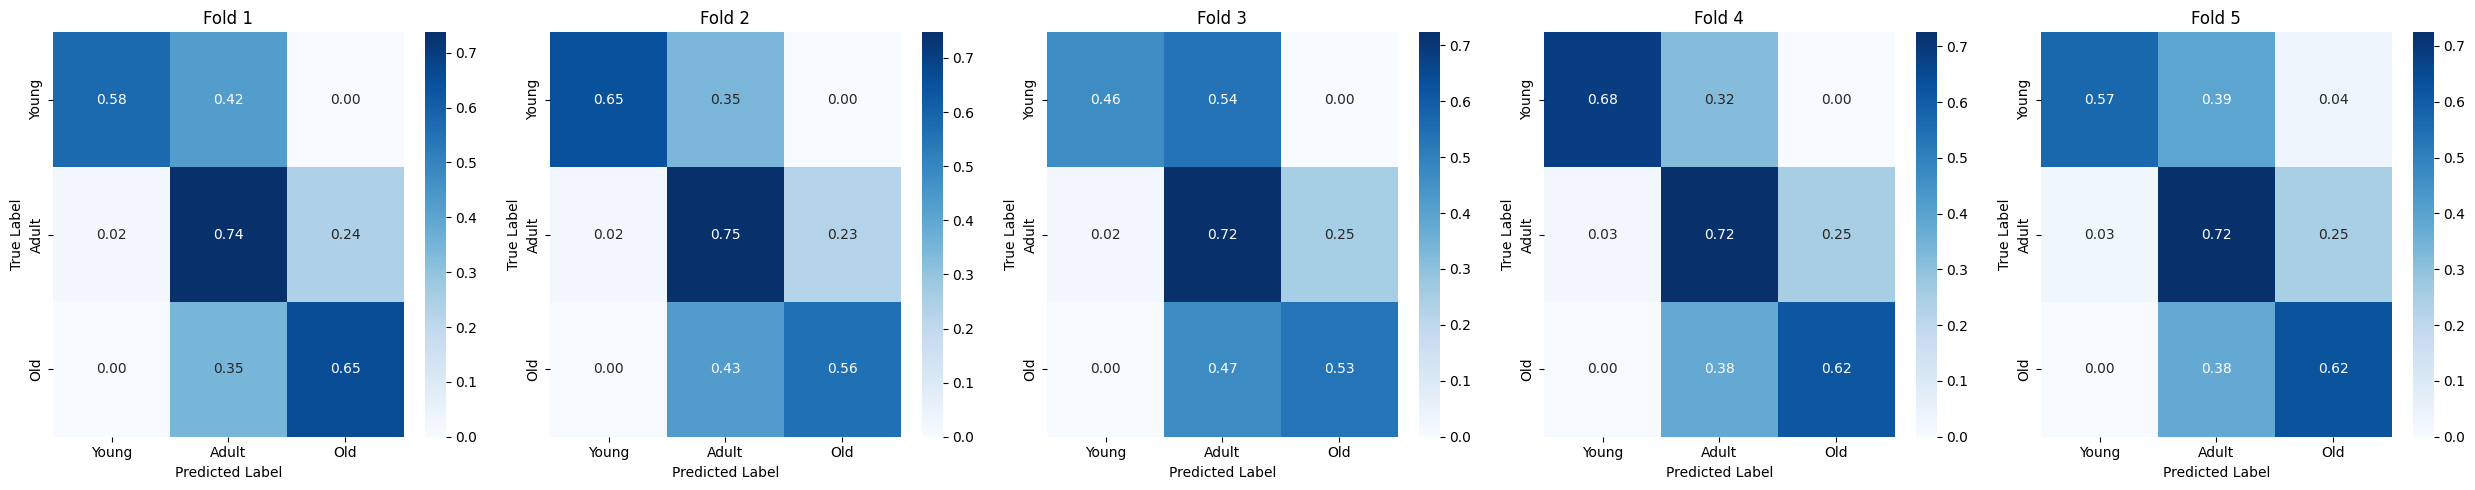

In [36]:
confusion_matrices_1, avg_accuracy_1, elapsed_time_1, last_dt_1 = k_fold_cross_validation_dt(X, y)
print(f"\nNo Pruning:")
print(f"Average Accuracy: {avg_accuracy_1:.4f}")
print(f"Elapsed Time: {elapsed_time_1:.4f} seconds")
print("Confusion Matrices:")
plot_confusion_matrices(confusion_matrices_1, LABELS, normalize=True)

## Comments:
Without pruning, the decision tree achieved an average accuracy of 67.88%, with a relatively low elapsed time of 73.40 seconds, making it computationally efficient. Although this is the worst result compared to the decision tree with pruning and the random forest models, it remains usable. When analyzing the confusion matrices, some folds show strong diagonal dominance (good predictions), while others show more off-diagonal errors, indicating that performance varies across folds depending on the distribution of samples.

# **Implementation of Decision Tree Testing Function with Pruning**:
In my decision tree implementation, I use pre-pruning with early stopping. I limit the maximum depth of the tree by decreasing a depth counter at each recursive call. If the maximum depth is reached or the node entropy falls below a predefined threshold, the recursion stops early and a leaf node is created using majority voting. This prevents overfitting and reduces the training time by avoiding unnecessary splits.

# Results of k-fold cross validation:


Pruning with max depth 5:
Average Accuracy: 0.7320
Elapsed Time: 63.2592 seconds
Confusion Matrices:


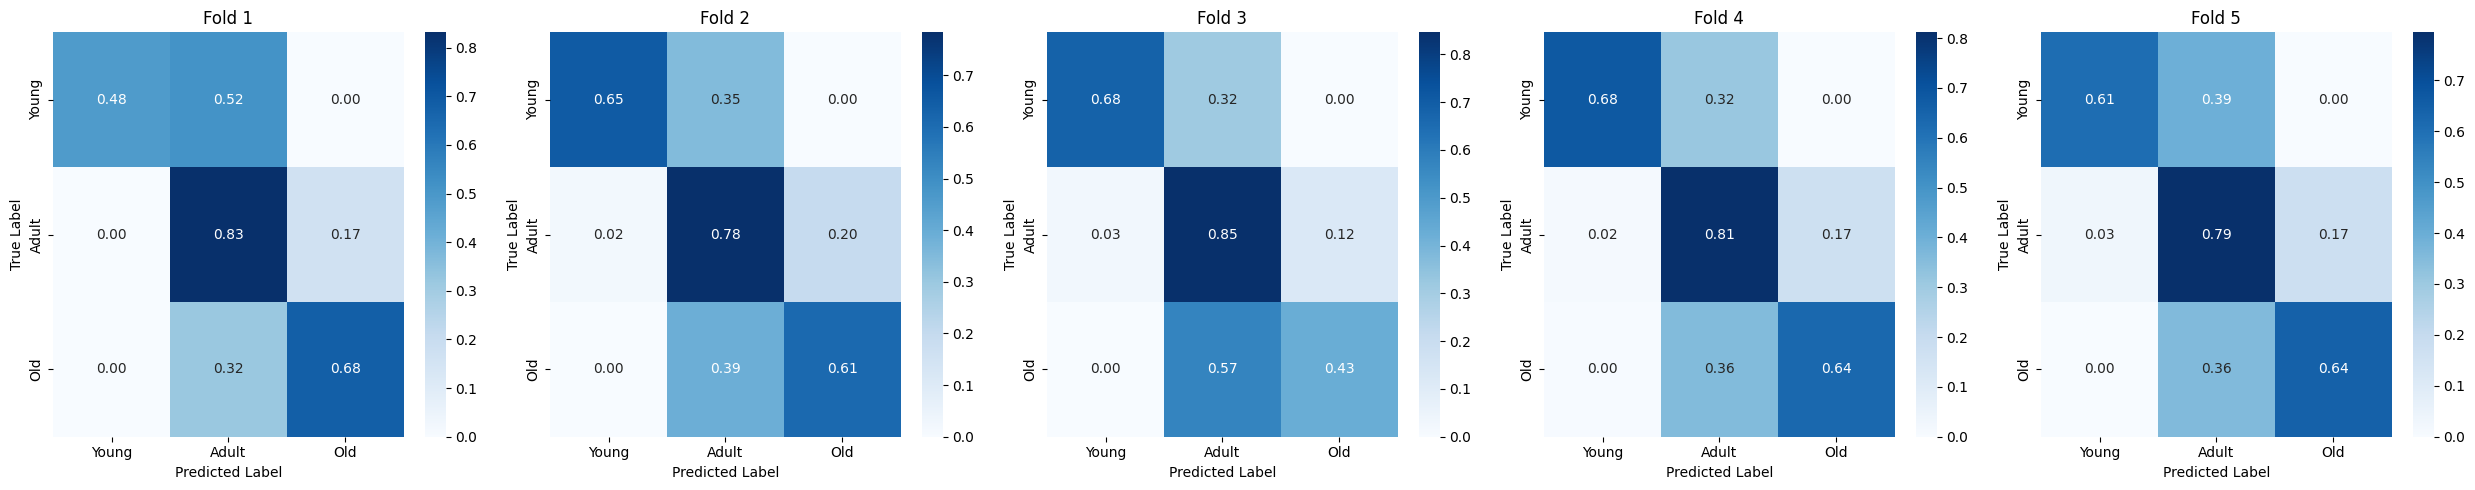

In [37]:
# Pruning with max depth 5
confusion_matrices_2, avg_accuracy_2, elapsed_time_2, last_dt_2 = k_fold_cross_validation_dt(X, y, options=[DT_TRESHOLD, 5])
print(f"\nPruning with max depth 5:")
print(f"Average Accuracy: {avg_accuracy_2:.4f}")
print(f"Elapsed Time: {elapsed_time_2:.4f} seconds")
print("Confusion Matrices:")
plot_confusion_matrices(confusion_matrices_2, LABELS, normalize=True)

## Comments:
With pruning (maximum depth 5), the decision tree achieved an average accuracy of 73.20%, while reducing the elapsed time to 63.26 seconds — the fastest among all models due to early stopping. Although some random forest models outperform it slightly in terms of accuracy, this pruned tree still provides strong performance. Analyzing the confusion matrices, some folds show better separation compared to the unpruned tree, while others perform slightly worse, showing that fold-specific variation remains.

# **Implementation of RDF:**

In [8]:
def build_rdf(X, y, attribute_types, N, options):
	if options is None:
		options = [DT_TRESHOLD, None, int(np.sqrt(len(X[0])))]
	forest = []
	d = len(X[0])  # total number of features
	k = options[2] if len(options) > 2 else int(np.sqrt(d))  # default: sqrt(d)

	for _ in range(N):
		# Bootstrap sample (with replacement)
		indices = np.random.choice(len(X), len(X), replace=True)
		X_sample = [X[i] for i in indices]
		y_sample = [y[i] for i in indices]

		# Random feature subset
		selected_features = sorted(np.random.choice(d, k, replace=False).tolist())

		# Reduce X_sample to selected features
		X_reduced = [[x[i] for i in selected_features] for x in X_sample]
		attr_types_reduced = [attribute_types[i] for i in selected_features]
  
		# Build tree using reduced feature set
		tree = build_dt(X_reduced, y_sample, attr_types_reduced, options)

		# Store both tree and selected feature indices
		forest.append((tree, selected_features))

	return forest

from collections import Counter

def predict_rdf(forest, X, options=None):
	predictions = []

	for x in X:
		votes = []
		for tree, selected_features in forest:
			x_reduced = [x[i] for i in selected_features]
			pred = predict_value(tree, x_reduced)
			votes.append(pred)

		# Majority vote
		prediction = Counter(votes).most_common(1)[0][0]
		predictions.append(prediction)

	return predictions


# Results of k-fold cross validation:


No Pruning:
Average Accuracy: 0.6857
Elapsed Time: 106.5814 seconds
Confusion Matrices:


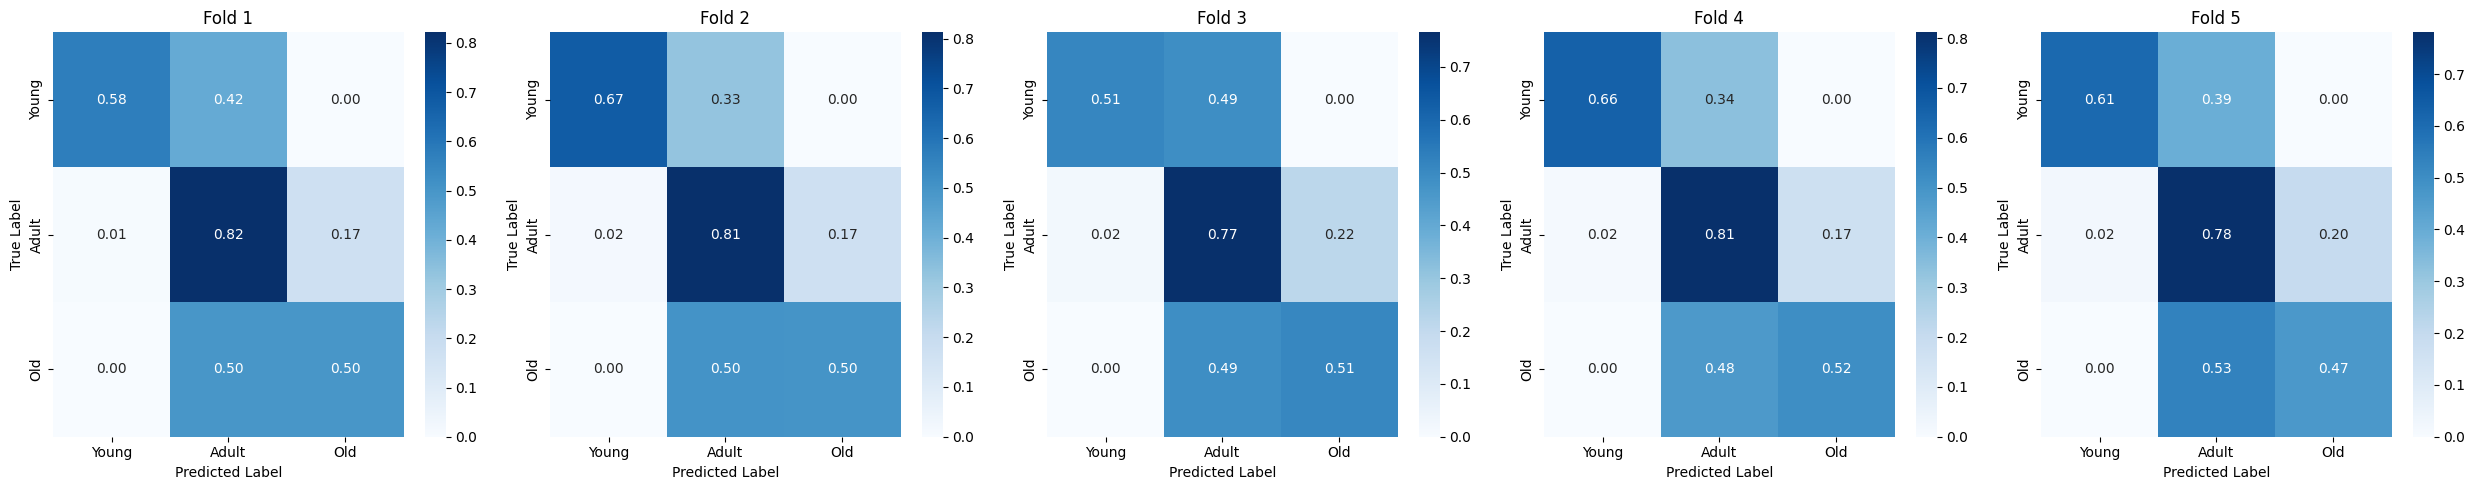


Pruning with max depth 5 and fc 3:
Average Accuracy: 0.7111
Elapsed Time: 115.9522 seconds
Confusion Matrices:


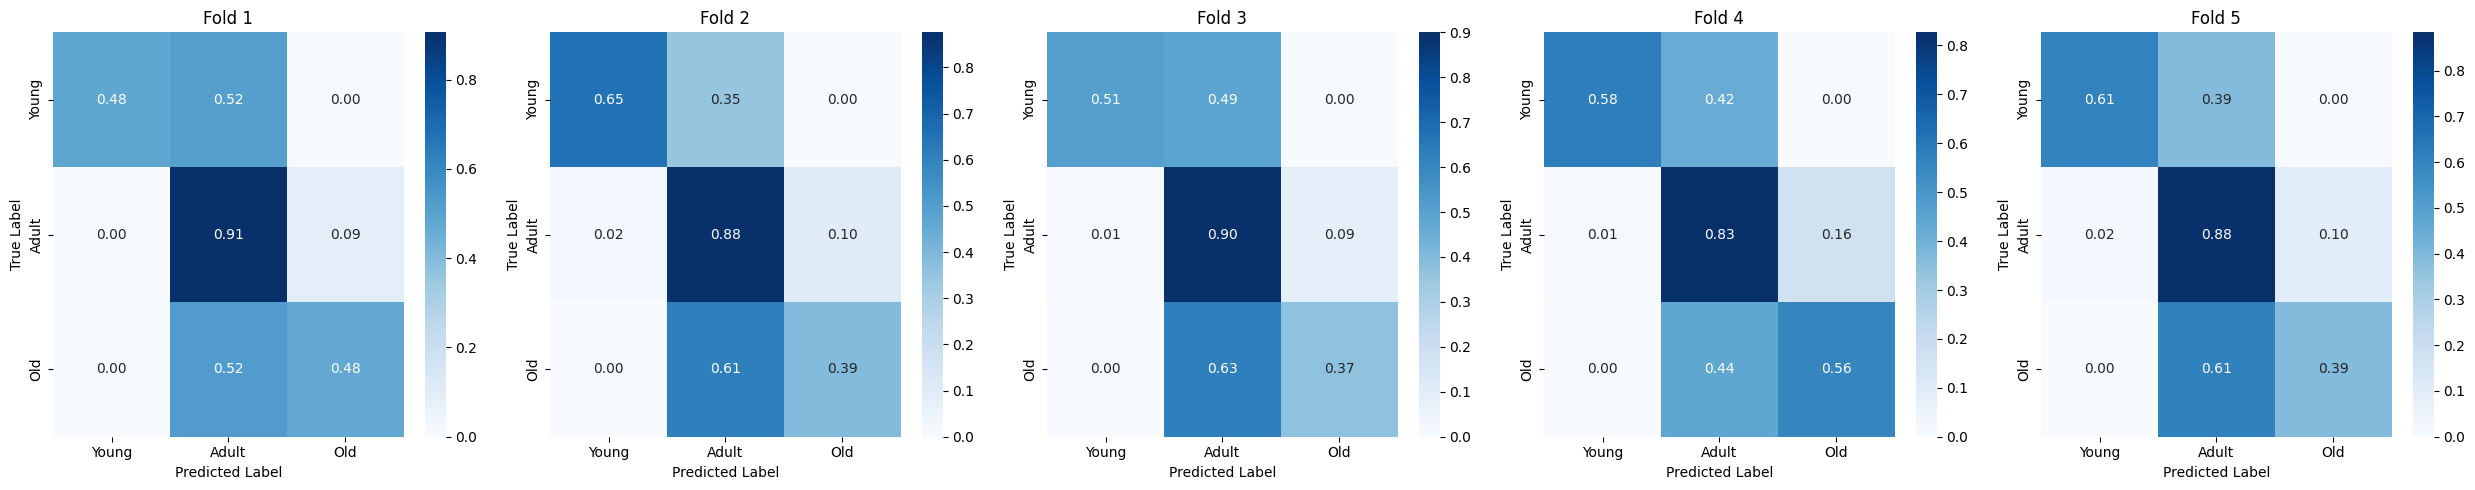


Pruning with max depth 5 and fc 5:
Average Accuracy: 0.7289
Elapsed Time: 216.2828 seconds
Confusion Matrices:


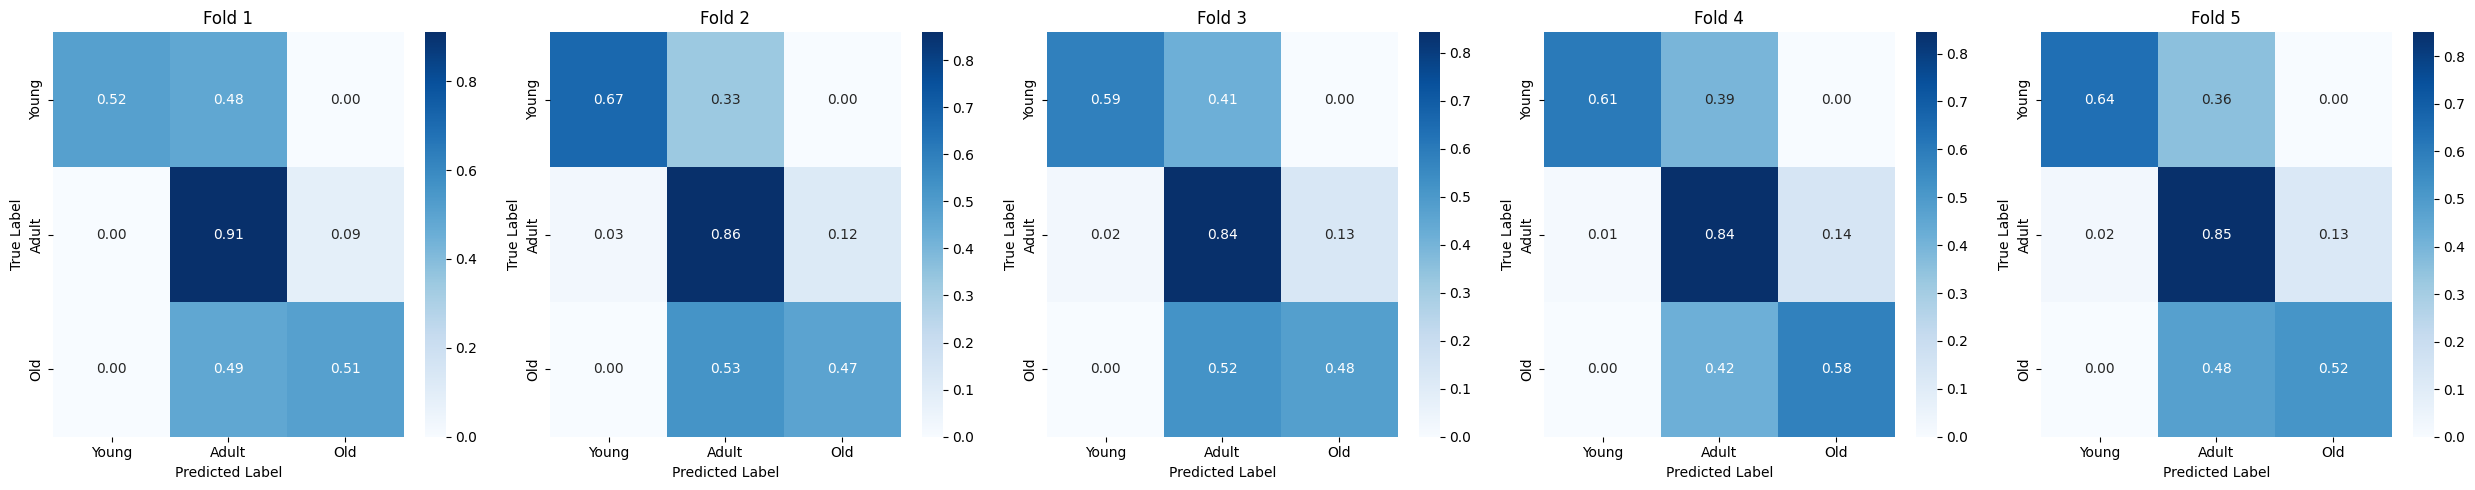


Pruning with max depth 5 and fc 8 (max):
Average Accuracy: 0.7430
Elapsed Time: 319.8662 seconds
Confusion Matrices:


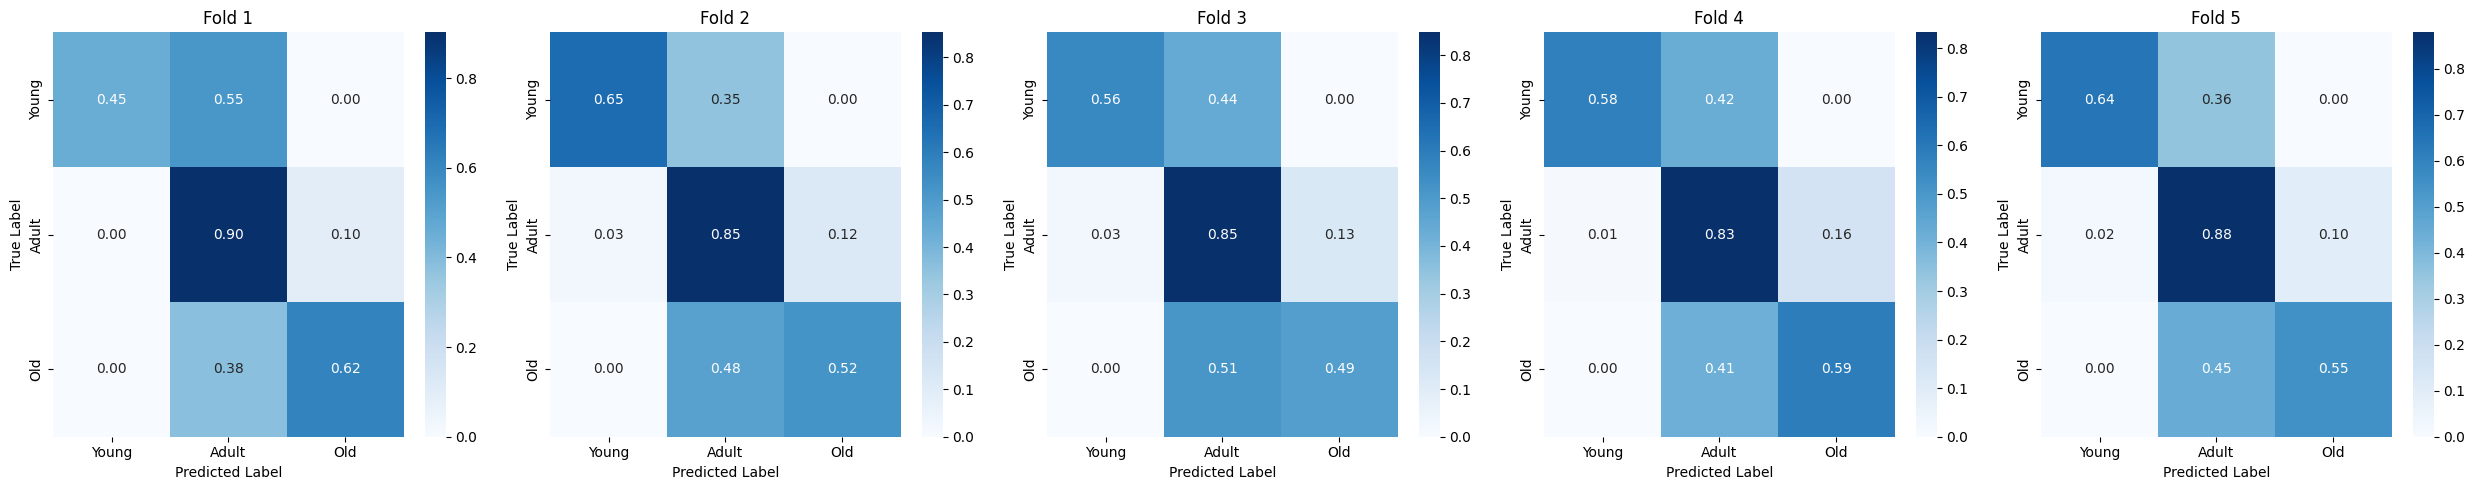

In [9]:
import time
import numpy as np
from collections import Counter

def k_fold_cross_validation_rdf(X, y, k_fold: int = K_FOLDS, N: int = 10, options=None):
	if k_fold < 1:
		raise ValueError("k_fold must be greater than 0")

	if len(y) == 0:
		raise ValueError("data must not be empty")

	if k_fold > len(y):
		k_fold = len(y)

	data_indices = list(range(len(y)))

	if RANDOM_STATE is not None:
		np.random.seed(RANDOM_STATE)

	np.random.shuffle(data_indices)

	fold_count = len(data_indices) // k_fold
	confusion_matrices = []
	accuracies = []

	start_time = time.time()

	for i in range(k_fold):
		test_indices = data_indices[i * fold_count:(i + 1) * fold_count]
		train_indices = [idx for idx in data_indices if idx not in test_indices]

		X_train = [X[i] for i in train_indices]
		y_train = [y[i] for i in train_indices]
		X_test = [X[i] for i in test_indices]
		y_test = [y[i] for i in test_indices]

		attribute_types = construct_feature_type_vector(X_train)

		# Build Random Forest
		rdf = build_rdf(X_train, y_train, attribute_types, N, options)

		# Predict with majority vote
		predictions = predict_rdf(rdf, X_test)

		# Accuracy
		accuracy = sum(yt == yp for yt, yp in zip(y_test, predictions)) / len(y_test)
		accuracies.append(accuracy)

		# Confusion matrix
		label_to_index = {label: i for i, label in enumerate(LABELS)}
		n_classes = len(LABELS)
		conf_matrix = np.zeros((n_classes, n_classes), dtype=int)

		for yt, yp in zip(y_test, predictions):
			i = label_to_index[yt]
			j = label_to_index[yp]
			conf_matrix[i][j] += 1

		confusion_matrices.append(conf_matrix)

	end_time = time.time()
	elapsed_time = end_time - start_time
	avg_accuracy = sum(accuracies) / len(accuracies)

	return confusion_matrices, avg_accuracy, elapsed_time, rdf

confusion_matrices_1, avg_accuracy_1, elapsed_time_1, last_dt_1 = k_fold_cross_validation_rdf(X, y)
print(f"\nNo Pruning:")
print(f"Average Accuracy: {avg_accuracy_1:.4f}")
print(f"Elapsed Time: {elapsed_time_1:.4f} seconds")
print("Confusion Matrices:")
plot_confusion_matrices(confusion_matrices_1, LABELS, normalize=True)

# Pruning with max depth 5, feature count 3
confusion_matrices_2, avg_accuracy_2, elapsed_time_2, last_dt_2 = k_fold_cross_validation_rdf(X, y, options=[DT_TRESHOLD, 5, 3])
print(f"\nPruning with max depth 5 and fc 3:")
print(f"Average Accuracy: {avg_accuracy_2:.4f}")
print(f"Elapsed Time: {elapsed_time_2:.4f} seconds")
print("Confusion Matrices:")
plot_confusion_matrices(confusion_matrices_2, LABELS, normalize=True)

# Pruning with max depth 5, feature count 5
confusion_matrices_2, avg_accuracy_2, elapsed_time_2, last_dt_2 = k_fold_cross_validation_rdf(X, y, options=[DT_TRESHOLD, 5, 5])
print(f"\nPruning with max depth 5 and fc 5:")
print(f"Average Accuracy: {avg_accuracy_2:.4f}")
print(f"Elapsed Time: {elapsed_time_2:.4f} seconds")
print("Confusion Matrices:")
plot_confusion_matrices(confusion_matrices_2, LABELS, normalize=True)

# Pruning with max depth 5, feature count 8 (max feature count)
confusion_matrices_2, avg_accuracy_2, elapsed_time_2, last_dt_2 = k_fold_cross_validation_rdf(X, y, options=[DT_TRESHOLD, 5, 8])
print(f"\nPruning with max depth 5 and fc 8 (max):")
print(f"Average Accuracy: {avg_accuracy_2:.4f}")
print(f"Elapsed Time: {elapsed_time_2:.4f} seconds")
print("Confusion Matrices:")
plot_confusion_matrices(confusion_matrices_2, LABELS, normalize=True)


Pruning with max depth 5, number of features 3, number of trees 30:
Average Accuracy: 0.7128
Elapsed Time: 383.0739 seconds
Confusion Matrices:


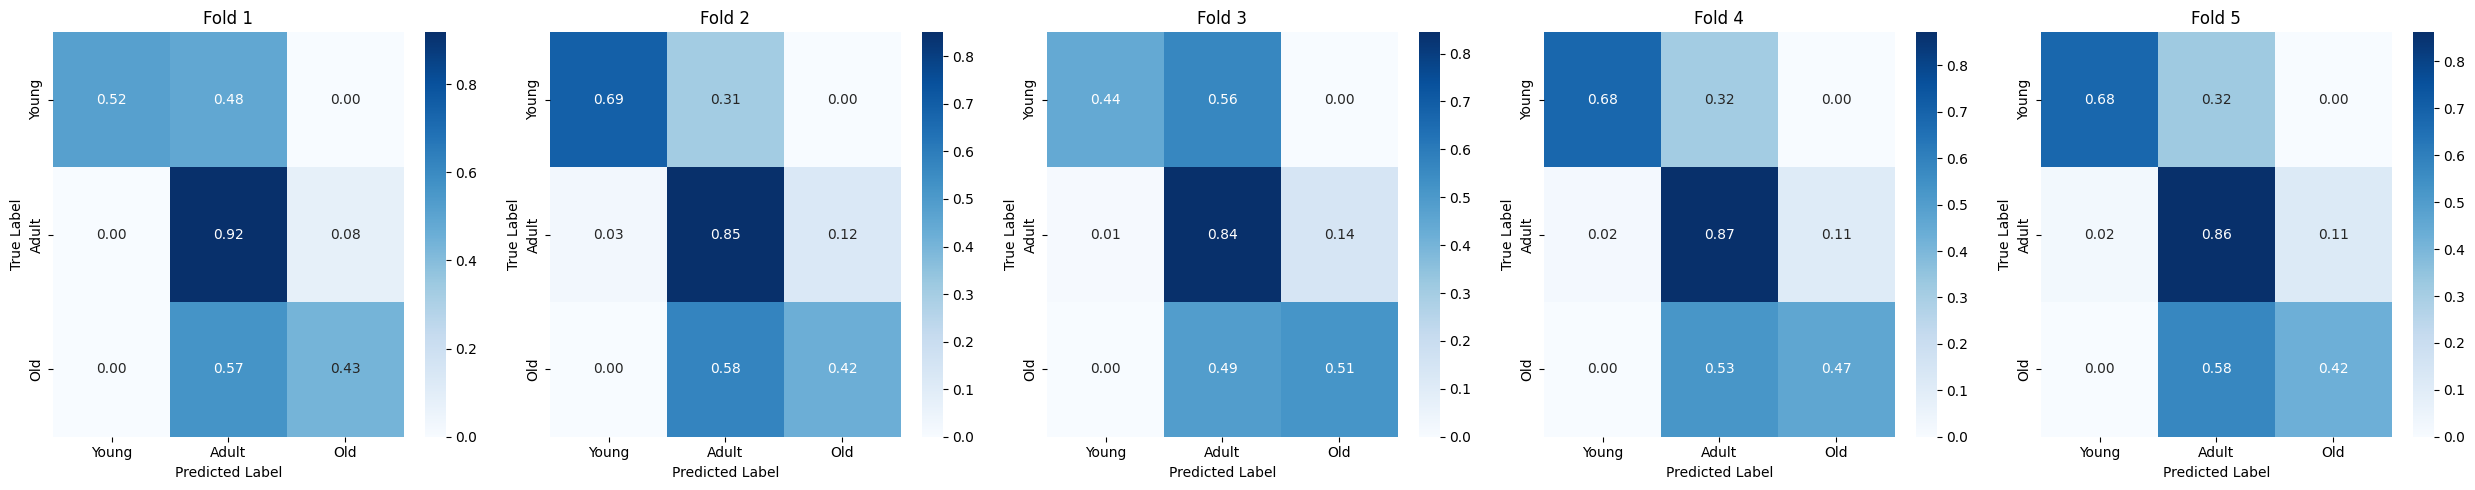

In [10]:
# Pruning with max depth 5, number of features 3, number of trees 30
confusion_matrices_2, avg_accuracy_2, elapsed_time_2, last_dt_2 = k_fold_cross_validation_rdf(X, y, N=30, options=[DT_TRESHOLD, 5, 3])
print(f"\nPruning with max depth 5, number of features 3, number of trees 30:")
print(f"Average Accuracy: {avg_accuracy_2:.4f}")
print(f"Elapsed Time: {elapsed_time_2:.4f} seconds")
print("Confusion Matrices:")
plot_confusion_matrices(confusion_matrices_2, LABELS, normalize=True)

## Comments:
In my random forest implementation, the default number of trees was set to 10 and the number of features considered at each split was √(feature count). Increasing the number of trees from 10 to 30 did not result in any significant improvement in accuracy, which is expected because after a certain point, adding more trees provides diminishing returns if the individual trees are already diverse enough. On the other hand, applying pruning (maximum depth 5) and increasing the number of features considered at each split improved the accuracy consistently. However, increasing the number of features also increased the training time significantly, as each tree became more complex and spent more time searching for optimal splits.